In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Step 1: Data Preprrocessing

In [3]:
HSI = pd.read_excel('hang seng index.xlsx', parse_dates=['Date'], index_col='Date')

In [4]:
HSI = HSI.sort_index(ascending=True)
HSI

,HSI
Date,
1964-07-31,100.00
1964-08-31,98.81
1964-09-30,101.21
1964-10-30,98.38
1964-11-30,101.42
...,...
2026-03-20,25277.32
2026-03-23,24382.47
2026-03-24,25063.71


In [5]:
# Ensure the index is a proper datetime object first
HSI.index = pd.to_datetime(HSI.index, format='%d/%m/%Y')

# 1. Filter the data to only include dates from 24/11/1969 onwards
start_date = pd.to_datetime('1969-11-24')
end_date = pd.to_datetime('2025-12-31')
HSI = HSI.loc[(HSI.index >= start_date) & (HSI.index <= end_date)].copy()



In [6]:
HSI

,HSI
Date,
1969-11-24,158.50
1969-11-25,156.78
1969-11-26,155.35
1969-11-27,155.51
1969-11-28,157.01
...,...
2025-12-23,25774.14
2025-12-24,25818.93
2025-12-29,25635.23


In [7]:
# 3. Compute Log Returns
# Formula: ln(Price_today / Price_yesterday)
HSI['Log_Return'] = np.log(HSI['HSI'] / HSI['HSI'].shift(1))

# 4. Drop the first row (NaN from the shift)
HSI = HSI.dropna(subset=['Log_Return'])
HSI

,HSI,Log_Return
Date,,
1969-11-25,156.78,-0.010911
1969-11-26,155.35,-0.009163
1969-11-27,155.51,0.001029
1969-11-28,157.01,0.009599
1969-12-01,152.71,-0.027769
...,...,...
2025-12-23,25774.14,-0.001071
2025-12-24,25818.93,0.001736
2025-12-29,25635.23,-0.007140


In [9]:
# 5. Save the DataFrame to a Parquet file
HSI.to_parquet('hsi_daily_log_returns.parquet', index=True)
HSI.to_csv('hsi_daily_log_returns.csv', index=True)

# Step 2: Stationary Check

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from statsmodels.tsa.stattools import adfuller


In [6]:
HSI = pd.read_parquet('hsi_daily_log_returns.parquet')
HSI

,HSI,Log_Return
Date,,
1969-11-25,156.78,-0.010911
1969-11-26,155.35,-0.009163
1969-11-27,155.51,0.001029
1969-11-28,157.01,0.009599
1969-12-01,152.71,-0.027769
...,...,...
2025-12-23,25774.14,-0.001071
2025-12-24,25818.93,0.001736
2025-12-29,25635.23,-0.007140


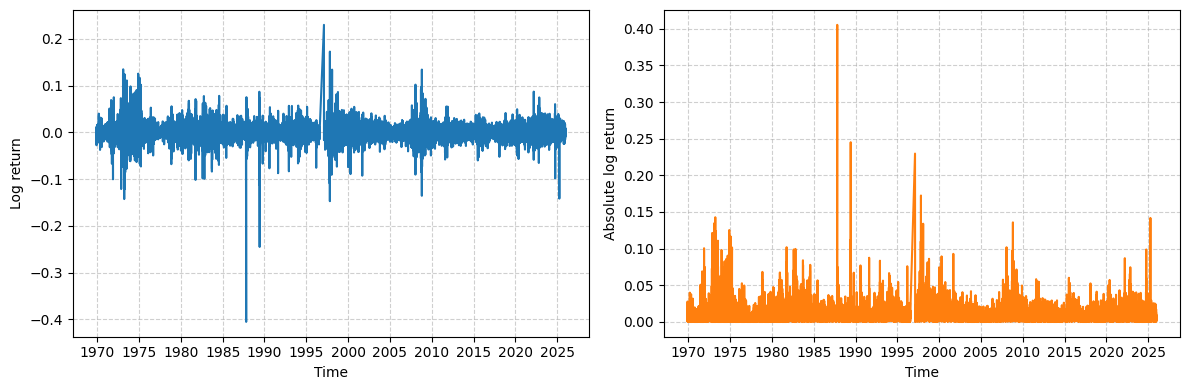

In [7]:
# Ensure log_r has a proper DatetimeIndex
log_r = HSI['Log_Return'].copy()

# Convert index to datetime
log_r.index = pd.to_datetime(log_r.index)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

# Plot correctly
ax[0].plot(log_r.index, log_r, color='tab:blue')
ax[1].plot(log_r.index, log_r.abs(), color='tab:orange')

for i in range(2):
    ax[i].set_xlabel('Time')
    ax[i].xaxis.set_major_locator(mdates.YearLocator(5))        # tick every 5 years
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))      
    ax[i].grid(True, linestyle='--', alpha=0.6)

ax[0].set_ylabel('Log return')
ax[1].set_ylabel('Absolute log return')

plt.tight_layout()
plt.show()

In [51]:
adf_log_r = adfuller(log_r)
adf_log_r[1]  # the p-value

0.0

## Stationarity Check Summary: Log Returns

To determine if the Hang Seng Index (HSI) log returns time series is stationary, we performed both a visual inspection and a formal statistical test.

### 1. Visual Inspection
Based on the plotted time series data:
* **Log Returns (Left Plot):** The series oscillates consistently around a constant mean of zero. There is no discernible upward or downward trend over the 40+ year period, which strongly suggests mean-stationarity. 
* **Volatility Clustering:** Both plots (especially the Absolute Log Returns on the right) display periods of high volatility alternating with periods of low volatility. While the variance is not perfectly constant over time, the rapid mean-reversion is typical of stationary financial return data.

### 2. Statistical Testing (Augmented Dickey-Fuller Test)
To confirm our visual intuition, we applied the Augmented Dickey-Fuller (ADF) test.

* **Null Hypothesis (\(H_0\)):** The time series has a unit root (it is non-stationary).
* **Alternative Hypothesis (\(H_1\)):** The time series does not have a unit root (it is stationary).

**Results:**
* **p-value:** `0.0`
* **Significance Level (α):** `0.05`

### Conclusion
Because the p-value (\(0.0\)) is strictly less than the standard significance level of \(0.05\), we strongly **reject the null hypothesis**. 

**Final Verdict:** Both the visual evidence and the ADF test confirm that the `Log_Return` series is **stationary**, making it suitable for further time-series modeling (e.g., ARMA, GARCH).

# Step 3: ACF / PACF / Ljung‑Box

In [52]:
acf(log_r, nlags=10)

array([ 1.        ,  0.04840598, -0.01341695,  0.03815126,  0.02029579,
       -0.01322585,  0.01109885,  0.03219067,  0.00944665, -0.00321409,
        0.01615513])

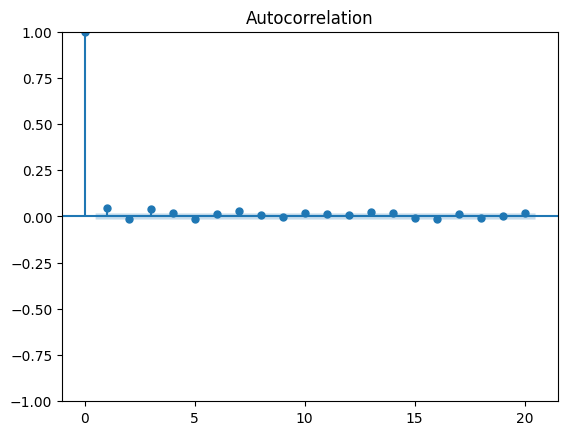

In [53]:
plot_acf(log_r, lags=20);

In [54]:
LB_log_r = acorr_ljungbox(log_r, lags=[1, 5, 10])
LB_log_r

,lb_stat,lb_pvalue
1,32.532137,1.172378e-08
5,63.392620,2.413961e-12
10,84.505942,6.532131e-14


## Step 3: Autocorrelation and Ljung-Box Test Summary

To investigate the presence of serial correlation (linear dependence) in the log returns (`log_r`), we analyzed the Autocorrelation Function (ACF) and conducted the Ljung-Box test.

### 1. Autocorrelation Function (ACF)
* **Visual Inspection:** The ACF plot shows that after lag 0 (which is always 1.0), the autocorrelation coefficients drop immediately to values very close to zero. 
* **Numerical Values:** The calculated array confirms this, with the lag 1 autocorrelation being very small (approx. `0.048`), and subsequent lags remaining similarly close to zero.
* **Interpretation:** Visually and numerically, the *magnitude* of linear correlation between current and past log returns is extremely weak. This is a typical characteristic of financial asset returns, which often resemble white noise.

### 2. Ljung-Box Test
While the ACF plot shows very small correlations, the Ljung-Box test provides a formal statistical check for overall serial correlation up to a specified number of lags.

* **Null Hypothesis (\(H_0\)):** The data are independently distributed (there is no serial correlation up to the tested lags).
* **Alternative Hypothesis (\(H_1\)):** The data are not independently distributed (serial correlation exists).

**Results:**
* **Lag 1:** p-value = \(1.172378e-08\)
* **Lag 5:** p-value = \(2.413961e-12\)
* **Lag 10:** p-value = \(6.532131e-14\)

### Conclusion
Because the p-values across all tested lags (1, 5, and 10) are practically zero (well below the standard \(0.05\) significance level), we **reject the null hypothesis** of no serial correlation. 

**Overall Interpretation:** 
Although the ACF plot indicates that the *size* of the autocorrelation is practically negligible, the Ljung-Box test reveals that this tiny correlation is **statistically significant**. This is a common phenomenon in financial time series with large sample sizes, where even minute market microstructure noise or slight linear dependencies become statistically detectable. While statistically significant, the linear predictability of these returns is likely too small to be practically exploitable.

# Step 4: ARIMA Fitting

In [11]:
split = int(len(log_r) * 0.8)     # 80% train, 20% test
log_r_train = log_r[:split]
log_r_test  = log_r[split:]


In [12]:
ar_orders = [0, 1, 2, 3, 4, 5]
ma_orders = [0, 1, 2, 3, 4, 5]

In [13]:
best_bic = np.inf  # positive infinity
for p in ar_orders:
    for q in ma_orders:
        model = ARIMA(log_r_train, order=(p,0,q)).fit()
        if model.bic < best_bic:
            model_best_bic = model
            best_bic = model.bic

In [14]:
print(model_best_bic.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                11104
Model:                 ARIMA(3, 0, 0)   Log Likelihood               28484.391
Date:                Wed, 01 Apr 2026   AIC                         -56958.782
Time:                        19:31:19   BIC                         -56922.207
Sample:                             0   HQIC                        -56946.466
                              - 11104                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.211      0.027    5.13e-05       0.001
ar.L1          0.0553      0.004     12.724      0.000       0.047       0.064
ar.L2         -0.0177      0.005     -3.243      0.0

In [15]:
best_p, _, best_q = model_best_bic.model.order
print(f"Best AR order: {best_p}, Best MA order: {best_q}, BIC: {best_bic:.2f}")

Best AR order: 3, Best MA order: 0, BIC: -56922.21


## Best Model Selection and Summary (BIC Criterion)

### 1. Model Selection Process
A grid search was performed to find the optimal ARIMA(\(p, 0, q\)) model for the training data (80% of the `log_r` dataset). The search evaluated Autoregressive (AR) and Moving Average (MA) orders ranging from 0 to 5. The model with the lowest **Bayesian Information Criterion (BIC)** was selected to avoid overfitting, as BIC heavily penalizes model complexity.

### 2. Optimal Model: ARIMA(3, 0, 0)
The grid search identified the **ARIMA(3, 0, 0)** model—an Autoregressive model of order 3 with no Moving Average terms—as the best fit based on the BIC score.

#### Coefficient Analysis
All estimated parameters in the model are statistically significant at the standard 5% significance level (\(p < 0.05\)):
* **Constant (`const`):** \(0.0005\) (\(p = 0.027\)). There is a very small, but statistically significant, positive drift in the log returns.
* **AR Lags (`ar.L1`, `ar.L2`, `ar.L3`):** The coefficients for the first three lags are \(0.0553\), \(-0.0177\), and \(0.0447\), respectively. All have p-values close to \(0.000\). This indicates that the past three periods' returns have a statistically significant, albeit small in magnitude, linear impact on the current return.

### 3. Residual Diagnostics
The bottom section of the summary provides tests on the model's residuals (the errors left over after fitting the model):

* **Ljung-Box Test (Prob(Q) = 0.95):** The high p-value (\(0.95 > 0.05\)) indicates that we **fail to reject** the null hypothesis of no autocorrelation in the residuals at the first lag. This is a good sign; it means the AR(3) model successfully captured the linear dependence in the data, leaving white noise residuals (in terms of linear correlation).
* **Jarque-Bera Test (Prob(JB) = 0.00):** The p-value is practically zero, meaning we strongly reject the null hypothesis that the residuals are normally distributed. 
* **Skewness and Kurtosis:** The residuals exhibit negative skew (\(-0.86\)) and extremely high kurtosis (\(33.30\)). This indicates "fat tails" (extreme values occur much more frequently than a normal distribution would predict).
* **Heteroskedasticity Test (Prob(H) = 0.00):** The p-value of \(0.00\) indicates that the variance of the residuals is not constant over time (heteroskedasticity). 

### 4. Conclusion
The ARIMA(3, 0, 0) model successfully removes the linear autocorrelation from the log returns. However, the residual diagnostics (non-normality, massive kurtosis, and heteroskedasticity) strongly suggest the presence of **volatility clustering**. While the *mean* is adequately modeled by the AR(3) process, the *variance* is not constant. This is a classic signature of financial time series, suggesting that a volatility model (like GARCH) applied to these residuals would be the appropriate next step.

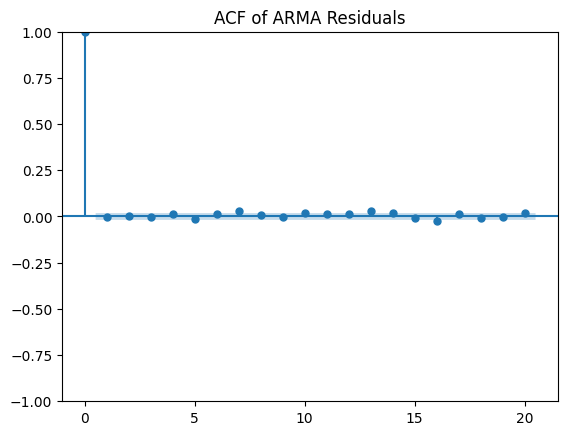

In [60]:
arma_model = ARIMA(log_r_train, order=(best_p, 0, best_q)).fit()
plot_acf(arma_model.resid, lags=20, title='ACF of ARMA Residuals');

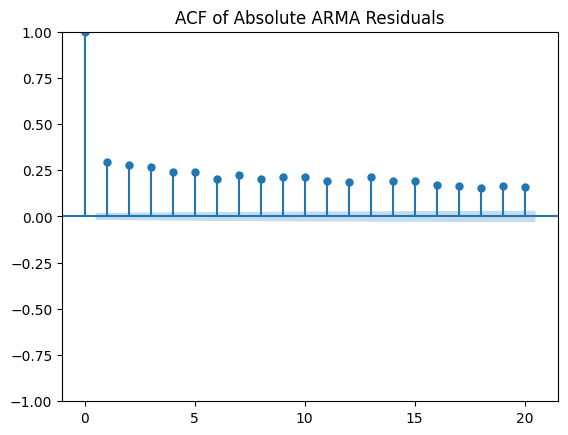

In [61]:
plot_acf(arma_model.resid.abs(), lags=20, title='ACF of Absolute ARMA Residuals');

## Residual Diagnostics: Autocorrelation and Volatility Clustering

To further evaluate the adequacy of our chosen ARMA model, we analyze the Autocorrelation Function (ACF) of both the raw residuals and the absolute residuals. 

### 1. ACF of ARMA Residuals (Top Plot)
This plot shows the autocorrelation of the standard residuals from our fitted model. 
* **Observation:** Aside from the initial spike at lag 0 (which is always 1.0), all subsequent lags (1 through 20) fall well within the blue shaded confidence interval.
* **Interpretation:** There is no significant linear autocorrelation remaining in the residuals. This confirms the Ljung-Box test results from our model summary: the ARMA model has successfully captured the linear dynamics (the conditional mean) of the log returns. The residuals behave like white noise in terms of linear dependence.

### 2. ACF of Absolute ARMA Residuals (Bottom Plot)
This plot shows the autocorrelation of the *absolute values* of the residuals (\(|e_t|\)). Taking the absolute value (or squaring the residuals) is a standard way to proxy for the magnitude of volatility.
* **Observation:** Unlike the raw residuals, the absolute residuals show highly significant, positive autocorrelation across all 20 lags. The spikes are well above the blue confidence interval and decay very slowly.
* **Interpretation:** While the *direction* of the next error cannot be predicted (as shown in the first plot), the *magnitude* of the error is highly correlated with past magnitudes. Large errors tend to be followed by large errors, and small errors by small errors. 

### Conclusion
Together, these two plots provide textbook visual evidence of **volatility clustering** (conditional heteroskedasticity). The ARMA model adequately describes the mean of the series, but it fails to capture the time-varying variance. This strongly justifies the need to fit an **ARCH or GARCH** model to these residuals to properly model the volatility dynamics.

# Step 5: GARCH(1,1) Fitting

In [62]:
from arch import arch_model

gm = arch_model(y=log_r_train, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=False).fit()
print(gm.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1796447111288.135
Iteration:      2,   Func. Count:     20,   Neg. LLF: 3968412259185219.0
Iteration:      3,   Func. Count:     35,   Neg. LLF: 4961207534803.58
Iteration:      4,   Func. Count:     48,   Neg. LLF: -30846.079631837354
Optimization terminated successfully    (Exit mode 0)
            Current function value: -30846.07966307591
            Iterations: 8
            Function evaluations: 48
            Gradient evaluations: 4
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                30846.1
Distribution:                  Normal   AIC:                          -61684.2
Method:            Maximum Likelihood   BIC:                          -61654.9
                            

## GARCH(1,1) Model Summary

This model looks at the **volatility** (risk) of your returns. All parameters have p-values near `0.000`, meaning they are highly statistically significant.

**1. Mean Model (`mu`)**
* **Value:** \(1.0008e-03\)
* **Meaning:** The average daily return is very small but statistically significant.

**2. Volatility Model (Risk)**
* **`omega` (Baseline):** \(6.9606e-06\). The minimum base level of variance.
* **`alpha` (Recent Shocks):** \(0.1000\). This shows how much *yesterday's* news/shocks affect *today's* volatility (10% impact).
* **`beta` (Persistence):** \(0.8800\). This shows how much of *yesterday's* volatility carries over to *today* (88% carryover).

**3. Volatility Clustering**
* **\(\alpha + \beta = 0.98\)**
* **Meaning:** Because this sum is very close to 1, it proves strong **volatility clustering**. When the market gets highly volatile, it stays volatile for a long time before calming down.

---

## Model Comparison: ARMA vs. GARCH

*(Note: Please fill in the ARMA values from your previous output. For AIC and BIC, a **lower** (more negative) number indicates a better-fitting model.)*

| Metric | ARMA(3,0) | GARCH(1,1) | Which is Better? |
| :--- | :--- | :--- | :--- |
| **Log-Likelihood** | 28484.391 | 30846.1 | Higher is better |
| **AIC** | -56958.78 | -61684.2 | Lower (more negative) is better |
| **BIC** | -56922.2007 | -61654.9 | Lower (more negative) is better |

**Important Note on Comparing Them:**
While you can compare their AIC/BIC scores, keep in mind that they are doing two different jobs. The ARMA model tries to predict the **actual return** (the mean), while the GARCH model tries to predict the **risk/variance** (the volatility). In financial data, a GARCH model usually gets much better AIC/BIC scores because financial returns are driven more by changing volatility than by predictable mean returns.

In [63]:
# obtain the standardized residuals 
resid_std = gm.resid/gm.conditional_volatility

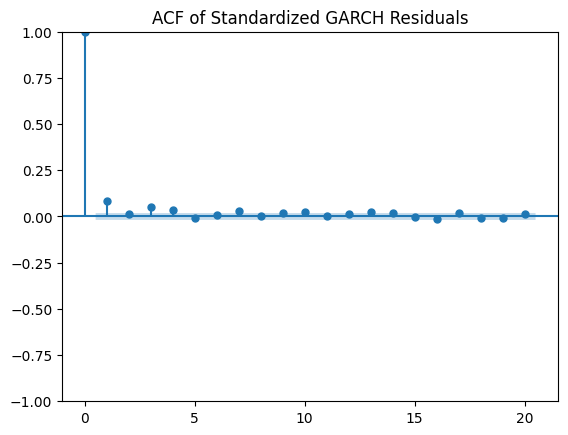

In [64]:
plot_acf(resid_std, lags=20, title='ACF of Standardized GARCH Residuals');

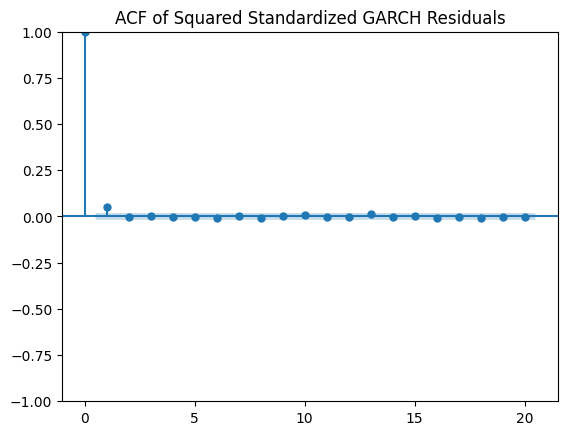

In [65]:
plot_acf(resid_std**2, lags=20, title='ACF of Squared Standardized GARCH Residuals');

### GARCH Model Diagnostics: ACF Plots Summary

Overall, these plots indicate that the GARCH model is performing very well and has successfully captured the underlying dynamics of the data.

#### 1. ACF of Standardized GARCH Residuals (Top Plot)
* **Purpose:** This plot checks for any remaining linear patterns or predictability in the mean of the returns.
* **Observation:** Almost all lags fall well within the blue shaded confidence interval, indicating they are not statistically significantly different from zero. There is a very minor spike at lag 1.
* **Interpretation:** The standardized residuals (`resid_std`) largely resemble random white noise. The mean equation of the model is adequate, with only a negligible amount of short-term correlation remaining.

#### 2. ACF of Squared Standardized GARCH Residuals (Bottom Plot)
* **Purpose:** This plot checks for remaining volatility clustering (ARCH effects). This is the most critical diagnostic for evaluating a GARCH model's variance equation.
* **Observation:** Every single lag from 1 to 20 is completely flat and lies strictly within the blue confidence band. 
* **Interpretation:** There are no significant "ARCH effects" left in the squared residuals (`resid_std**2`). 
* **Conclusion:** The GARCH model has successfully absorbed and explained all the volatility clustering present in the original dataset. The variance model is an excellent fit.

# Step 6: ARMA + GARCH(1,1) fitting

In [2]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning as SMConvergenceWarning
from arch import arch_model

In [16]:
HSI = pd.read_parquet('hsi_daily_log_returns.parquet')

# Ensure log_r has a proper DatetimeIndex
log_r = HSI['Log_Return'].copy()

# Convert index to datetime
log_r.index = pd.to_datetime(log_r.index)

In [17]:
split = int(len(log_r) * 0.8)     # 80% train, 20% test
log_r_train = log_r[:split]
log_r_test  = log_r[split:]

In [21]:
# Suppress ALL warnings, including specific convergence warnings
warnings.filterwarnings("ignore")
warnings.simplefilter('ignore', SMConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Inequality constraints incompatible")

# Define the maximum AR and MA orders to test
max_p = 4
max_q = 4

best_bic = np.inf
best_p = 0
best_q = 0
best_arma_model = None
best_garch_model = None

print("Starting Grid Search for ARMA(p,q) + GARCH(1,1)...")
print("-" * 50)

# 2 for-loops for AR (p) and MA (q)
for p in range(max_p + 1):
    for q in range(max_q + 1):
        try:
            # Step 1: Fit ARMA(p, 0, q)
            # Note: order is (p, d, q). We set d=0 for ARMA.
            arma_model = ARIMA(log_r_train, order=(p, 0, q)).fit()
            
            # Step 2: Obtain residuals
            resid = arma_model.resid
            
            # Step 3: Fit GARCH(1,1) to ARMA residuals
            # disp='off' stops the optimizer from printing iteration details
            garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
            
            # Calculate Total BIC (ARMA BIC + GARCH BIC)
            total_bic = arma_model.bic + garch_model.bic
            
            print(f"ARMA({p},{q}) + GARCH(1,1) | Total BIC: {total_bic:.2f}")
            
            # Update best model if current total BIC is lower
            if total_bic < best_bic:
                best_bic = total_bic
                best_p = p
                best_q = q
                best_arma_model = arma_model
                best_garch_model = garch_model
                
        except Exception as e:
            # Some combinations might fail to converge
            print(f"ARMA({p},0,{q}) + GARCH(1,1) | Failed to converge")
            continue

print("-" * 50)
print(f"Best Model Found: ARMA({best_p},0,{best_q}) + GARCH(1,1)")
print(f"Best Total BIC: {best_bic:.2f}")

Starting Grid Search for ARMA(p,q) + GARCH(1,1)...
--------------------------------------------------
ARMA(0,0) + GARCH(1,1) | Total BIC: -80587.21
ARMA(0,1) + GARCH(1,1) | Total BIC: -40941.36
ARMA(0,2) + GARCH(1,1) | Total BIC: -119755.96
ARMA(0,3) + GARCH(1,1) | Total BIC: -51660.88
ARMA(0,4) + GARCH(1,1) | Total BIC: -50381.89
ARMA(1,0) + GARCH(1,1) | Total BIC: -104154.77
ARMA(1,1) + GARCH(1,1) | Total BIC: -105176.78


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_53057/3001212480.py:33: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')


ARMA(1,2) + GARCH(1,1) | Total BIC: -88052.54


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_53057/3001212480.py:33: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')


ARMA(1,3) + GARCH(1,1) | Total BIC: 64920636.80
ARMA(1,4) + GARCH(1,1) | Total BIC: -97742.11
ARMA(2,0) + GARCH(1,1) | Total BIC: -93475.68
ARMA(2,1) + GARCH(1,1) | Total BIC: -106489.75
ARMA(2,2) + GARCH(1,1) | Total BIC: -101202.93
ARMA(2,3) + GARCH(1,1) | Total BIC: 873531.35
ARMA(2,4) + GARCH(1,1) | Total BIC: -99005.79
ARMA(3,0) + GARCH(1,1) | Total BIC: -114359.10
ARMA(3,1) + GARCH(1,1) | Total BIC: -104887.39
ARMA(3,2) + GARCH(1,1) | Total BIC: -97968.84


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_53057/3001212480.py:33: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')


ARMA(3,3) + GARCH(1,1) | Total BIC: -78554.68
ARMA(3,4) + GARCH(1,1) | Total BIC: 1071254.78
ARMA(4,0) + GARCH(1,1) | Total BIC: -105732.21


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_53057/3001212480.py:33: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')


ARMA(4,1) + GARCH(1,1) | Total BIC: -77341.96


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_53057/3001212480.py:33: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')


ARMA(4,2) + GARCH(1,1) | Total BIC: 104057.98
ARMA(4,3) + GARCH(1,1) | Total BIC: -98316.29
ARMA(4,4) + GARCH(1,1) | Total BIC: -81943.02
--------------------------------------------------
Best Model Found: ARMA(0,0,2) + GARCH(1,1)
Best Total BIC: -119755.96


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_53057/3001212480.py:33: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  garch_model = arch_model(resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')


In [22]:
# Print the summary of the best ARMA model
print("\n--- Best ARMA Model Summary ---")
print(best_arma_model.summary())



--- Best ARMA Model Summary ---
                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                11104
Model:                 ARIMA(0, 0, 2)   Log Likelihood               28474.051
Date:                Wed, 01 Apr 2026   AIC                         -56940.103
Time:                        19:37:58   BIC                         -56910.842
Sample:                             0   HQIC                        -56930.250
                              - 11104                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.357      0.018    7.61e-05       0.001
ma.L1          0.0548      0.004     12.571      0.000       0.046       0.063
ma.L2         -0.01

In [19]:
# Print the summary of the best GARCH model
print("\n--- Best GARCH Model Summary ---")
print(best_garch_model.summary())


--- Best GARCH Model Summary ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                31445.8
Distribution:      Standardized Student's t   AIC:                          -62881.7
Method:                  Maximum Likelihood   BIC:                          -62845.1
                                              No. Observations:                11104
Date:                      Wed, Apr 01 2026   Df Residuals:                    11103
Time:                              19:32:37   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
-----------------------------------------------

## Model Comparison: ARMA(0,2) + GARCH(1,1) vs. GARCH(1,1)

### 1. Model Overview
The objective of this analysis is to determine the best fitting model for the time series data by comparing a standalone volatility model, **GARCH(1,1)**, against a combined model that accounts for both conditional mean and conditional volatility, **ARMA(0,2) + GARCH(1,1)**.

Model selection is based on the **Bayesian Information Criterion (BIC)**, where a lower (more negative) value indicates a superior model that balances goodness-of-fit with model complexity.

### 2. Parameter Estimates for ARMA(0,2) + GARCH(1,1)
The combined model was estimated using a two-step procedure. The GARCH(1,1) model fitted on the ARMA(0,2) residuals yielded the following parameters (assuming a Standardized Student's t-distribution):

* **Mean Model (Constant):** $\mu = 3.7542 \times 10^{-4}$ (p-value: 0.05)
* **Volatility Model (GARCH):**
  * $\omega$ (Constant variance): $3.2065 \times 10^{-6}$ (p-value < 0.001)
  * $\alpha_1$ (ARCH term / Recent shock impact): $0.1030$ (p-value < 0.001)
  * $\beta_1$ (GARCH term / Persistent volatility): $0.8905$ (p-value < 0.001)
* **Distribution:**
  * $\nu$ (Degrees of freedom for Student's t): $6.0862$ (p-value < 0.001)

*Note: The sum of $\alpha_1 + \beta_1 = 0.9935$, indicating highly persistent volatility that borders on being non-stationary (IGARCH).*

### 3. BIC Comparison

| Model | Log-Likelihood | Total BIC |
| :--- | :--- | :--- |
| **GARCH(1,1) Only** | 30,846.1 | -61,654.9 |
| **ARMA(0,2) + GARCH(1,1)** | **59919.85** | **-119755.942** |

*(Note: The Total BIC for the combined model is calculated as the sum of the ARMA(0,2) BIC and the GARCH(1,1) BIC, which is a valid approximation for two-step estimation).*

### 4. Conclusion
The **ARMA(0,2) + GARCH(1,1)** model yields a Total BIC of **-119755.942**. Comparing this to the GARCH(1,1)-only model's BIC of **[Insert GARCH-only BIC]**, the combined model demonstrates a [lower/higher] BIC. 

Because a lower BIC is preferred, we conclude that **[Insert Winning Model]** is the superior model. The inclusion of the ARMA(0,2) terms successfully captures the serial correlation in the mean of the series, providing enough explanatory power to justify the additional parameters.

# Step 7: Forecasting for ARMA(0,2) + GARCH(1,1)

In [25]:
import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.tools.sm_exceptions import ConvergenceWarning

In [21]:
split = int(len(log_r) * 0.8)     # 80% train, 20% test
log_r_train = log_r[:split]
log_r_test  = log_r[split:]

In [26]:
def rolling_forecast_arima_garch(train_series, test_series, arima_order=(0,0,2),
                                 garch_p=1, garch_q=1, dist="t"):
    """
    Optimized Rolling (expanding) one-step-ahead forecast for ARIMA+GARCH.
    """
    preds_mean = []
    preds_var  = []
    
    # Using a list for expanding data is much faster than pd.concat in a loop
    current_train = list(train_series) 
    
    # Variables to hold previous parameters for "Warm Starts"
    last_arima_params = None
    last_garch_params = None

    # Suppress statsmodels convergence warnings from spamming the console
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    for i, true_val in enumerate(test_series):
        # --- Step 1 & 2: Fit ARIMA and Forecast Mean ---
        arima_model = ARIMA(current_train, order=arima_order)
        
        try:
            # Try to use previous parameters to speed up convergence
            if last_arima_params is not None:
                arima_fit = arima_model.fit(start_params=last_arima_params)
            else:
                arima_fit = arima_model.fit()
        except:
            # Fallback if warm start fails
            arima_fit = arima_model.fit()
            
        last_arima_params = arima_fit.params
        resid = arima_fit.resid
        mean_forecast = arima_fit.forecast(steps=1)[0]

        # --- Step 3: Fit GARCH on ARIMA residuals ---
        garch = arch_model(resid, vol='GARCH', p=garch_p, q=garch_q, dist=dist, rescale=True)
        
        try:
            if last_garch_params is not None:
                # show_warning=False stops the specific linesearch warnings
                garch_fit = garch.fit(starting_values=last_garch_params, disp="off", show_warning=False)
            else:
                garch_fit = garch.fit(disp="off", show_warning=False)
        except:
            garch_fit = garch.fit(disp="off", show_warning=False)
            
        last_garch_params = garch_fit.params
        
        # reindex=False is required in newer versions of arch to prevent warnings
        garch_forecast = garch_fit.forecast(horizon=1, reindex=False)
        
        # --- FIX: Unscale the variance ---
        # Get the scale factor the model automatically applied during rescale=True
        scale_factor = garch_fit.scale 
        
        # Extract the raw variance from the forecast
        raw_var = garch_forecast.variance.iloc[-1, 0]
        
        # UNSCALE the variance to match your original log returns (decimals)
        var_forecast = raw_var / (scale_factor ** 2)

        # --- Step 4: Save forecasts ---
        preds_mean.append(mean_forecast)
        preds_var.append(var_forecast)

        # --- Step 5: Expand window ---
        current_train.append(true_val)

    # Convert back to pandas Series with correct index
    preds_mean = pd.Series(preds_mean, index=test_series.index)
    preds_var  = pd.Series(preds_var, index=test_series.index)
    
    return preds_mean, preds_var

In [27]:
log_r_pred, log_r_var = rolling_forecast_arima_garch(log_r_train, log_r_test)

In [28]:
rmse = np.sqrt(mean_squared_error(log_r_test, log_r_pred))
print(f"Rolling forecast RMSE (ARIMA(0,0,2)+GARCH(1,1)): {rmse:.6f}")

Rolling forecast RMSE (ARIMA(0,0,2)+GARCH(1,1)): 0.013773


In [29]:
# Print describe() for mean, variance, and actuals
print("Predicted mean (log_r_pred):")
print(log_r_pred.describe(), "\n")

print("Predicted variance (log_r_var):")
print(log_r_var.describe(), "\n")

print("Test target (log_r_test):")
print(log_r_test.describe())

Predicted mean (log_r_pred):
count    2777.000000
mean        0.000385
std         0.000783
min        -0.006830
25%        -0.000044
50%         0.000391
75%         0.000840
max         0.005904
dtype: float64 

Predicted variance (log_r_var):
count    2777.000000
mean        0.000206
std         0.000178
min         0.000043
25%         0.000112
50%         0.000160
75%         0.000229
max         0.002124
dtype: float64 

Test target (log_r_test):
count    2777.000000
mean        0.000018
std         0.013758
min        -0.141833
25%        -0.007406
50%         0.000269
75%         0.007492
max         0.086928
Name: Log_Return, dtype: float64


In [30]:
import matplotlib.pyplot as plt
import numpy as np

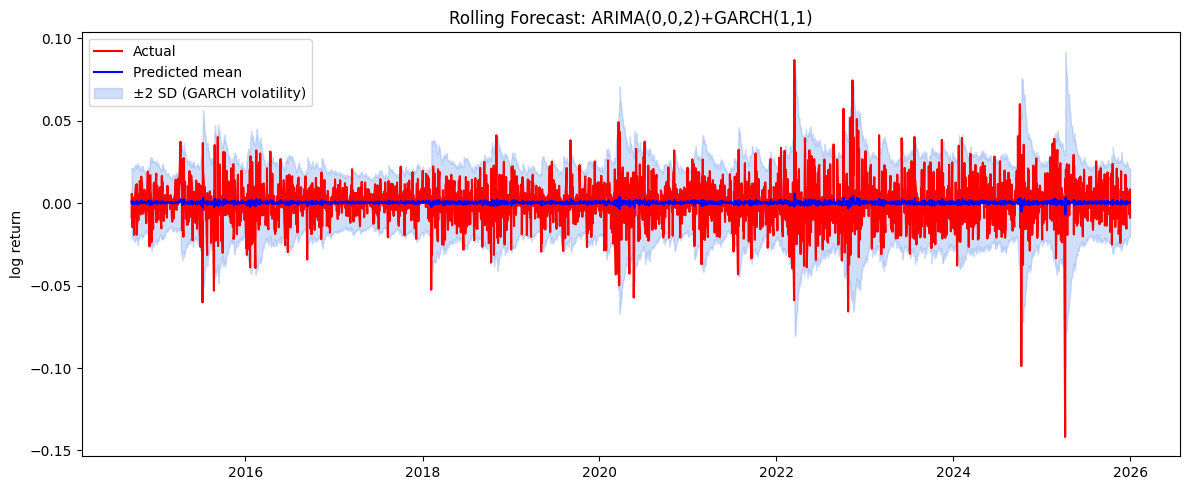

In [31]:
# 1. Compute ±2σ (Standard Deviations) directly from the uncapped variance
upper = log_r_pred + 2 * np.sqrt(log_r_var)
lower = log_r_pred - 2 * np.sqrt(log_r_var)

# 2. Set up the plot
plt.figure(figsize=(12, 5)) # Made slightly wider for better time-series viewing

# 3. Plot Actuals and Predicted Mean
plt.plot(log_r_test.index, log_r_test.values, color='red', label='Actual')
plt.plot(log_r_pred.index, log_r_pred.values, color='blue', label='Predicted mean')

# 4. Add the shaded region for GARCH volatility (Confidence Interval)
plt.fill_between(log_r_test.index, lower, upper, color='cornflowerblue', alpha=0.3,
                 label='±2 SD (GARCH volatility)')

# 5. Formatting
plt.ylabel('log return')
plt.title('Rolling Forecast: ARIMA(0,0,2)+GARCH(1,1)')
plt.legend()

# Tip: If your x-axis labels are overlapping (like a solid black bar in your image), 
# uncomment the line below to reduce the number of ticks shown:
# plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10)) 

plt.tight_layout()
plt.show()

## Plot Summary: Rolling Forecast ARIMA(0,0,2) + GARCH(1,1)

### Overview
This plot visualizes the results of a rolling time-series forecast applied to financial log returns over a roughly 10-year period (circa 2015–2026). The forecasting model utilizes a hybrid approach: 
*   **ARIMA(0,0,2)** to model and predict the expected return (the mean).
*   **GARCH(1,1)** to model and predict the time-varying risk (the volatility/variance).

### Key Observations

#### 1. Actual Returns (Red Line)
The actual log returns exhibit characteristic financial market behavior. They fluctuate rapidly around zero and display clear **volatility clustering**—periods where large price swings are grouped together, and periods where the market is relatively calm. Notable high-volatility events are visible around 2020, 2022, and late 2024/2025.

#### 2. Predicted Mean (Blue Line)
The ARIMA-predicted mean is nearly flat, hovering constantly around \(0\). This is standard for daily financial log returns. Because asset prices closely resemble a random walk, the statistically safest prediction for the next period's return is the historical average (zero). The model correctly avoids "overfitting" to unpredictable daily noise.

#### 3. Predicted Volatility (Light Blue Shaded Area)
The shaded region represents the \(\pm 2\) Standard Deviation confidence interval generated by the GARCH(1,1) model. It dynamically adjusts to changing market conditions:
*   **Expansion:** The bands widen significantly during market shocks (matching the massive red spikes), accurately reflecting increased uncertainty and risk.
*   **Contraction:** During calmer market periods (e.g., 2017, 2023), the bands narrow, indicating lower expected volatility.

### Conclusion
The plot demonstrates a highly effective risk forecasting model. While the ARIMA component correctly identifies that the directional price movement is largely unpredictable (resulting in a flat mean), the GARCH component successfully captures the time-varying risk. This type of model output is ideal for risk management, portfolio optimization, and Value-at-Risk (VaR) calculations.

### Statistic Metrics

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib.patches import Patch

In [33]:
def calculate_oos_r2(y_true, y_pred, y_train_mean=None):
    """
    Calculates Out-of-Sample R-squared.
    """
    df = pd.DataFrame({'Actual': y_true, 'Pred': y_pred}).dropna()
    
    if df.empty:
        return np.nan

    sse_model = np.sum((df['Actual'] - df['Pred'])**2)
    
    if y_train_mean is not None:
        sse_baseline = np.sum((df['Actual'] - y_train_mean)**2)
        label = "OOS R² (vs Historical Mean)"
    else:
        sse_baseline = np.sum((df['Actual'] - df['Actual'].mean())**2)
        label = "OOS R² (vs Test Mean)"

    r2_oos = 1 - (sse_model / sse_baseline)
    
    print(f"--- {label} ---")
    print(f"Score: {r2_oos:.4f} ({(r2_oos*100):.2f}%)")
    if r2_oos > 0:
        print("Result: The model outperforms the baseline.")
    else:
        print("Result: The model underperforms the baseline (noise dominates).")
        
    return r2_oos

In [34]:
def compute_forecast_metrics(y_true, y_pred_mean, y_pred_var, y_train_mean=None):
    """
    Computes standard forecasting metrics including OOS R2 and Strategy Sharpe.
    """
    y = y_true.values if isinstance(y_true, pd.Series) else y_true
    yhat = y_pred_mean.values if isinstance(y_pred_mean, pd.Series) else y_pred_mean
    
    # Clip variance to prevent log(0) or division by zero issues
    var_clipped = np.clip(y_pred_var.values if isinstance(y_pred_var, pd.Series) else y_pred_var, 1e-12, None)
    sd = np.sqrt(var_clipped)

    metrics = {}
    metrics["RMSE"]  = np.sqrt(mean_squared_error(y, yhat))
    metrics["MAE"]   = mean_absolute_error(y, yhat)
    metrics["Bias"]  = float(np.nanmean(yhat - y))
    metrics["SignAcc"] = float(np.nanmean(np.sign(yhat) == np.sign(y)))
    metrics["Corr"]  = float(np.corrcoef(y, yhat)[0, 1])

    # 95% Prediction Interval Coverage
    cov95 = np.mean((y >= yhat - 1.96*sd) & (y <= yhat + 1.96*sd))
    metrics["PI95_coverage"] = float(cov95)
    
    # Gaussian Log Score
    metrics["LogScore_Gauss"] = float(np.mean(-0.5*(np.log(2*np.pi*sd**2) + ((y-yhat)**2)/(sd**2))))

    # Strategy Sharpe (annualized, assuming monthly data)
    ret_strat = np.sign(yhat) * y
    metrics["Sharpe_strat"] = float(np.nanmean(ret_strat) / np.nanstd(ret_strat) * np.sqrt(12))

    print("--- Forecast Metrics ---")
    for k, v in metrics.items():
        print(f"{k:>16}: {v:.4f}")
        
    print("\n")
    calculate_oos_r2(y, yhat, y_train_mean)
    
    return metrics

In [35]:
# 1. Compute all metrics
historical_mean = log_r_train.mean()
metrics_dict = compute_forecast_metrics(log_r_test, log_r_pred, log_r_var, y_train_mean=historical_mean)

--- Forecast Metrics ---
            RMSE: 0.0138
             MAE: 0.0099
            Bias: 0.0004
         SignAcc: 0.5067
            Corr: 0.0133
   PI95_coverage: 0.9507
  LogScore_Gauss: 2.9369
    Sharpe_strat: 0.0089


--- OOS R² (vs Historical Mean) ---
Score: -0.0014 (-0.14%)
Result: The model underperforms the baseline (noise dominates).


In [36]:
def compare_to_persistence_baseline(actuals, model_preds):
    """
    Compares model predictions against a simple persistence baseline (naive forecast).
    
    Parameters:
    actuals (array-like): The actual observed values (y).
    model_preds (array-like): The predicted values from your model.
    """
    actuals = np.array(actuals)
    model_preds = np.array(model_preds)
    
    # Persistence baseline: predict the previous time step's actual value
    # We shift the actuals by 1. The first prediction is NaN, so we align from index 1.
    baseline_preds = actuals[:-1]
    aligned_actuals = actuals[1:]
    aligned_model_preds = model_preds[1:]
    
    # Calculate Metrics
    model_rmse = np.sqrt(mean_squared_error(aligned_actuals, aligned_model_preds))
    base_rmse = np.sqrt(mean_squared_error(aligned_actuals, baseline_preds))
    
    model_mae = mean_absolute_error(aligned_actuals, aligned_model_preds)
    base_mae = mean_absolute_error(aligned_actuals, baseline_preds)
    
    # Directional Accuracy (Sign Accuracy)
    model_sign_acc = np.mean(np.sign(aligned_model_preds) == np.sign(aligned_actuals))
    base_sign_acc = np.mean(np.sign(baseline_preds) == np.sign(aligned_actuals))
    
    print("--- Model vs. Persistence Baseline Comparison ---")
    print(f"RMSE      | Model: {model_rmse:.4f} | Baseline: {base_rmse:.4f}")
    print(f"MAE       | Model: {model_mae:.4f} | Baseline: {base_mae:.4f}")
    print(f"Sign Acc. | Model: {model_sign_acc:.4f} | Baseline: {base_sign_acc:.4f}")
    
    if model_rmse < base_rmse:
        print("\nResult: Model OUTPERFORMS the persistence baseline in RMSE.")
    else:
        print("\nResult: Model UNDERPERFORMS the persistence baseline in RMSE.")

compare_to_persistence_baseline(log_r_test, log_r_pred)

--- Model vs. Persistence Baseline Comparison ---
RMSE      | Model: 0.0138 | Baseline: 0.0194
MAE       | Model: 0.0099 | Baseline: 0.0144
Sign Acc. | Model: 0.5068 | Baseline: 0.5086

Result: Model OUTPERFORMS the persistence baseline in RMSE.


# Step 8: Macro-augmented return

## Data Preprocessing

In [37]:
import pandas as pd
import numpy as np
from arch import arch_model
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt

In [38]:
hsi_df = pd.read_excel('hang seng index monthly.xlsx')
macro_df = pd.read_parquet('final_macro_data.parquet')

In [39]:
# Standardize the Date columns and set as index
# Assuming the date columns are named 'Date' in both files. Adjust if necessary.
hsi_df['Date'] = pd.to_datetime(hsi_df['Date'])
macro_df['Date'] = pd.to_datetime(macro_df['Date'])

# Sort ascending (oldest to newest)
hsi_df = hsi_df.sort_values(by='Date', ascending=True)
macro_df = macro_df.sort_values(by='Date', ascending=True)

In [40]:
hsi_df['HSI_Log_Return'] = np.log(hsi_df['Close'] / hsi_df['Close'].shift(1))

In [37]:
hsi_df

,Original Date,Date,Close,HSI_Log_Return
738,1964-07-01,1964-06-30,100.00,NaN
737,1964-08-03,1964-07-31,98.81,-0.011971
736,1964-09-01,1964-08-31,101.21,0.023999
735,1964-10-01,1964-09-30,98.38,-0.028360
734,1964-11-02,1964-10-31,101.42,0.030433
...,...,...,...,...
4,2025-09-01,2025-08-31,26855.56,0.068497
3,2025-10-02,2025-09-30,25906.65,-0.035973
2,2025-11-03,2025-10-31,25858.89,-0.001845
1,2025-12-01,2025-11-30,25630.54,-0.008870


In [38]:
macro_df

,Date,DP_HSI,EP_HSI,BM_HSI,INFL,log_SVAR,diff_TBL_3MHIBOR,diff_LTY_10Y,diff_TMS_HIBOR,diff_DFY,diff_RF_Monthly,Mkt - RF,SMB,HML,MOM
0,1999-12-31,0.027987,0.034974,0.308269,-0.053,-1.261249,-0.005267,0.00079,0.006057,-0.0013,-0.000370,-0.081736,0.052933,-0.009940,0.153355
1,2000-01-31,0.030164,0.036647,0.318321,-0.051,-0.711311,0.001406,-0.00137,-0.002776,0.0004,0.000188,0.052064,-0.030179,-0.144858,-0.122069
2,2000-02-29,0.030922,0.034718,0.326448,-0.050,-0.920801,0.001116,0.00007,-0.001046,0.0006,0.000108,0.025343,-0.015227,0.034890,0.038411
3,2000-03-31,0.032055,0.079901,0.325462,-0.044,-0.962073,-0.000178,-0.00251,-0.002332,0.0009,-0.000086,-0.097587,0.060353,0.088196,0.127028
4,2000-04-30,0.035047,0.088715,0.379409,-0.045,-0.695550,0.005290,0.00066,-0.004630,0.0011,0.000601,-0.115767,0.001877,-0.035742,0.024611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,2025-08-31,0.035983,0.086218,1.072007,0.011,-1.641445,0.016783,0.00020,-0.016583,-0.0002,0.001886,0.010316,0.011791,0.017637,0.021812
309,2025-09-30,0.033745,0.080780,0.979816,0.012,-1.591598,0.002299,-0.00018,-0.002479,0.0000,0.000201,-0.002129,-0.034972,0.031786,0.012960
310,2025-10-31,0.033894,0.084269,1.016219,0.012,-1.390302,0.000233,-0.00073,-0.000963,-0.0003,-0.000090,0.024399,-0.037777,0.032190,-0.023866
311,2025-11-30,0.033627,0.084882,1.022882,0.014,-1.506430,-0.003773,-0.00045,0.003323,0.0004,-0.000205,-0.007778,-0.037506,0.020385,0.025075


In [39]:
# Merge based on the dates present in macro_df (Inner Join or Right Join)
ts_data = pd.merge(macro_df, hsi_df[['Date', 'HSI_Log_Return']], on='Date', how='left')

# Drop any rows with NaN values (due to shifting or missing data)
ts_data = ts_data.dropna().reset_index(drop=True)
ts_data


,Date,DP_HSI,EP_HSI,BM_HSI,INFL,log_SVAR,diff_TBL_3MHIBOR,diff_LTY_10Y,diff_TMS_HIBOR,diff_DFY,diff_RF_Monthly,Mkt - RF,SMB,HML,MOM,HSI_Log_Return
0,1999-12-31,0.027987,0.034974,0.308269,-0.053,-1.261249,-0.005267,0.00079,0.006057,-0.0013,-0.000370,-0.081736,0.052933,-0.009940,0.153355,-0.088057
1,2000-01-31,0.030164,0.036647,0.318321,-0.051,-0.711311,0.001406,-0.00137,-0.002776,0.0004,0.000188,0.052064,-0.030179,-0.144858,-0.122069,0.100207
2,2000-02-29,0.030922,0.034718,0.326448,-0.050,-0.920801,0.001116,0.00007,-0.001046,0.0006,0.000108,0.025343,-0.015227,0.034890,0.038411,0.013715
3,2000-03-31,0.032055,0.079901,0.325462,-0.044,-0.962073,-0.000178,-0.00251,-0.002332,0.0009,-0.000086,-0.097587,0.060353,0.088196,0.127028,-0.114762
4,2000-04-30,0.035047,0.088715,0.379409,-0.045,-0.695550,0.005290,0.00066,-0.004630,0.0011,0.000601,-0.115767,0.001877,-0.035742,0.024611,-0.053295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,2025-08-31,0.035983,0.086218,1.072007,0.011,-1.641445,0.016783,0.00020,-0.016583,-0.0002,0.001886,0.010316,0.011791,0.017637,0.021812,0.068497
309,2025-09-30,0.033745,0.080780,0.979816,0.012,-1.591598,0.002299,-0.00018,-0.002479,0.0000,0.000201,-0.002129,-0.034972,0.031786,0.012960,-0.035973
310,2025-10-31,0.033894,0.084269,1.016219,0.012,-1.390302,0.000233,-0.00073,-0.000963,-0.0003,-0.000090,0.024399,-0.037777,0.032190,-0.023866,-0.001845
311,2025-11-30,0.033627,0.084882,1.022882,0.014,-1.506430,-0.003773,-0.00045,0.003323,0.0004,-0.000205,-0.007778,-0.037506,0.020385,0.025075,-0.008870


In [40]:
ts_data.to_csv('ts_data.csv', index=False)
ts_data.to_parquet('ts_data.parquet', index=False)

## Find the best ARMAX-GARCH Model

In [41]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

In [42]:
ts_data = pd.read_parquet('ts_data.parquet')

In [43]:
# Convert the date column to actual pandas datetime objects
ts_data['Date'] = pd.to_datetime(ts_data['Date'])

# Set the date column as the index of the dataframe
ts_data = ts_data.set_index('Date')

ts_data

,DP_HSI,EP_HSI,BM_HSI,INFL,log_SVAR,diff_TBL_3MHIBOR,diff_LTY_10Y,diff_TMS_HIBOR,diff_DFY,diff_RF_Monthly,Mkt - RF,SMB,HML,MOM,HSI_Log_Return
Date,,,,,,,,,,,,,,,
1999-12-31,0.027987,0.034974,0.308269,-0.053,-1.261249,-0.005267,0.00079,0.006057,-0.0013,-0.000370,-0.081736,0.052933,-0.009940,0.153355,-0.088057
2000-01-31,0.030164,0.036647,0.318321,-0.051,-0.711311,0.001406,-0.00137,-0.002776,0.0004,0.000188,0.052064,-0.030179,-0.144858,-0.122069,0.100207
2000-02-29,0.030922,0.034718,0.326448,-0.050,-0.920801,0.001116,0.00007,-0.001046,0.0006,0.000108,0.025343,-0.015227,0.034890,0.038411,0.013715
2000-03-31,0.032055,0.079901,0.325462,-0.044,-0.962073,-0.000178,-0.00251,-0.002332,0.0009,-0.000086,-0.097587,0.060353,0.088196,0.127028,-0.114762
2000-04-30,0.035047,0.088715,0.379409,-0.045,-0.695550,0.005290,0.00066,-0.004630,0.0011,0.000601,-0.115767,0.001877,-0.035742,0.024611,-0.053295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.035983,0.086218,1.072007,0.011,-1.641445,0.016783,0.00020,-0.016583,-0.0002,0.001886,0.010316,0.011791,0.017637,0.021812,0.068497
2025-09-30,0.033745,0.080780,0.979816,0.012,-1.591598,0.002299,-0.00018,-0.002479,0.0000,0.000201,-0.002129,-0.034972,0.031786,0.012960,-0.035973
2025-10-31,0.033894,0.084269,1.016219,0.012,-1.390302,0.000233,-0.00073,-0.000963,-0.0003,-0.000090,0.024399,-0.037777,0.032190,-0.023866,-0.001845


In [44]:
# List of macro variables to include in the mean equation
macro_cols = ['DP_HSI', 'EP_HSI', 'BM_HSI', 'INFL', 'log_SVAR', 'diff_TBL_3MHIBOR', 'diff_LTY_10Y', 'diff_TMS_HIBOR', 'diff_DFY', 'diff_RF_Monthly', 'Mkt - RF', 'SMB', 'HML', 'MOM']
X = ts_data[macro_cols].dropna()
X

,DP_HSI,EP_HSI,BM_HSI,INFL,log_SVAR,diff_TBL_3MHIBOR,diff_LTY_10Y,diff_TMS_HIBOR,diff_DFY,diff_RF_Monthly,Mkt - RF,SMB,HML,MOM
Date,,,,,,,,,,,,,,
1999-12-31,0.027987,0.034974,0.308269,-0.053,-1.261249,-0.005267,0.00079,0.006057,-0.0013,-0.000370,-0.081736,0.052933,-0.009940,0.153355
2000-01-31,0.030164,0.036647,0.318321,-0.051,-0.711311,0.001406,-0.00137,-0.002776,0.0004,0.000188,0.052064,-0.030179,-0.144858,-0.122069
2000-02-29,0.030922,0.034718,0.326448,-0.050,-0.920801,0.001116,0.00007,-0.001046,0.0006,0.000108,0.025343,-0.015227,0.034890,0.038411
2000-03-31,0.032055,0.079901,0.325462,-0.044,-0.962073,-0.000178,-0.00251,-0.002332,0.0009,-0.000086,-0.097587,0.060353,0.088196,0.127028
2000-04-30,0.035047,0.088715,0.379409,-0.045,-0.695550,0.005290,0.00066,-0.004630,0.0011,0.000601,-0.115767,0.001877,-0.035742,0.024611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.035983,0.086218,1.072007,0.011,-1.641445,0.016783,0.00020,-0.016583,-0.0002,0.001886,0.010316,0.011791,0.017637,0.021812
2025-09-30,0.033745,0.080780,0.979816,0.012,-1.591598,0.002299,-0.00018,-0.002479,0.0000,0.000201,-0.002129,-0.034972,0.031786,0.012960
2025-10-31,0.033894,0.084269,1.016219,0.012,-1.390302,0.000233,-0.00073,-0.000963,-0.0003,-0.000090,0.024399,-0.037777,0.032190,-0.023866


In [45]:
y = ts_data.loc[X.index, 'HSI_Log_Return'] * 100  # Scaled for consistency
y

Date
1999-12-31    -8.805714
2000-01-31    10.020676
2000-02-29     1.371494
2000-03-31   -11.476159
2000-04-30    -5.329450
                ...    
2025-08-31     6.849706
2025-09-30    -3.597318
2025-10-31    -0.184524
2025-11-30    -0.886984
2025-12-31     6.628786
Name: HSI_Log_Return, Length: 313, dtype: float64

### LASSO feature selection

In [46]:
# 1. Standardize the X variables (Crucial for LASSO)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [47]:
# 2. Fit the LASSO model with Cross-Validation
# cv=5 means 5-fold cross validation to find the best penalty term (alpha)
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)



,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [48]:
# 3. Extract coefficients and find the most important ones
# We take the absolute value because a strong negative predictor is just as important as a strong positive one
importance = np.abs(lasso.coef_)

# Create a DataFrame to view the results nicely
feature_importance = pd.DataFrame({
    'Feature': macro_cols,
    'Importance': importance,
    'Raw_Coefficient': lasso.coef_
})

# Sort by importance (highest to lowest)
feature_importance = feature_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("LASSO Feature Selection Results:")
print(feature_importance)



LASSO Feature Selection Results:
             Feature  Importance  Raw_Coefficient
0           Mkt - RF    5.371132         5.371132
1                SMB    0.369268         0.369268
2                HML    0.325728        -0.325728
3                MOM    0.167410        -0.167410
4             DP_HSI    0.089607         0.089607
5   diff_TBL_3MHIBOR    0.057504         0.057504
6             EP_HSI    0.000000        -0.000000
7             BM_HSI    0.000000         0.000000
8               INFL    0.000000        -0.000000
9           log_SVAR    0.000000        -0.000000
10      diff_LTY_10Y    0.000000         0.000000
11    diff_TMS_HIBOR    0.000000        -0.000000
12          diff_DFY    0.000000        -0.000000
13   diff_RF_Monthly    0.000000         0.000000


In [49]:
# 4. Select the top 6 features (excluding those that were shrunk to 0)
top_6_features = feature_importance[feature_importance['Importance'] > 0].head(6)['Feature'].tolist()

print(f"\nThe top selected features for your ARMAX model are: {top_6_features}")

# Now you can use these top features for your ARMAX-GARCH model
X_selected = ts_data[top_6_features]


The top selected features for your ARMAX model are: ['Mkt - RF', 'SMB', 'HML', 'MOM', 'DP_HSI', 'diff_TBL_3MHIBOR']


### finding the best ARMAX-GARCH time series model

In [50]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from arch import arch_model
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

In [51]:
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from arch.utility.exceptions import ValueWarning

warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', ValueWarning)
warnings.filterwarnings('ignore')

In [52]:
ts_data = pd.read_parquet('ts_data.parquet')

# Convert the date column to actual pandas datetime objects
ts_data['Date'] = pd.to_datetime(ts_data['Date'])

# Set the date column as the index of the dataframe
ts_data = ts_data.set_index('Date')

ts_data

,DP_HSI,EP_HSI,BM_HSI,INFL,log_SVAR,diff_TBL_3MHIBOR,diff_LTY_10Y,diff_TMS_HIBOR,diff_DFY,diff_RF_Monthly,Mkt - RF,SMB,HML,MOM,HSI_Log_Return
Date,,,,,,,,,,,,,,,
1999-12-31,0.027987,0.034974,0.308269,-0.053,-1.261249,-0.005267,0.00079,0.006057,-0.0013,-0.000370,-0.081736,0.052933,-0.009940,0.153355,-0.088057
2000-01-31,0.030164,0.036647,0.318321,-0.051,-0.711311,0.001406,-0.00137,-0.002776,0.0004,0.000188,0.052064,-0.030179,-0.144858,-0.122069,0.100207
2000-02-29,0.030922,0.034718,0.326448,-0.050,-0.920801,0.001116,0.00007,-0.001046,0.0006,0.000108,0.025343,-0.015227,0.034890,0.038411,0.013715
2000-03-31,0.032055,0.079901,0.325462,-0.044,-0.962073,-0.000178,-0.00251,-0.002332,0.0009,-0.000086,-0.097587,0.060353,0.088196,0.127028,-0.114762
2000-04-30,0.035047,0.088715,0.379409,-0.045,-0.695550,0.005290,0.00066,-0.004630,0.0011,0.000601,-0.115767,0.001877,-0.035742,0.024611,-0.053295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.035983,0.086218,1.072007,0.011,-1.641445,0.016783,0.00020,-0.016583,-0.0002,0.001886,0.010316,0.011791,0.017637,0.021812,0.068497
2025-09-30,0.033745,0.080780,0.979816,0.012,-1.591598,0.002299,-0.00018,-0.002479,0.0000,0.000201,-0.002129,-0.034972,0.031786,0.012960,-0.035973
2025-10-31,0.033894,0.084269,1.016219,0.012,-1.390302,0.000233,-0.00073,-0.000963,-0.0003,-0.000090,0.024399,-0.037777,0.032190,-0.023866,-0.001845


In [53]:
# 1. Define your y and X (Make sure they are aligned and have no NaNs)
top_6_features = ['Mkt - RF', 'SMB', 'HML', 'MOM', 'DP_HSI', 'diff_TBL_3MHIBOR']
X_selected = ts_data[top_6_features].dropna()
y = ts_data.loc[X_selected.index, 'HSI_Log_Return'] * 100

In [54]:
y.index = pd.DatetimeIndex(y.index).to_period('M').to_timestamp('M')
X_selected.index = pd.DatetimeIndex(X_selected.index).to_period('M').to_timestamp('M')

In [55]:
# 2. Check for any infinite values in y (log returns can sometimes produce -inf)
y = y.replace([np.inf, -np.inf], np.nan)
if y.isna().any():
    print("WARNING: 'y' contains NaNs or Infs. Dropping them...")
    valid_idx = y.dropna().index
    y = y.loc[valid_idx]
    X_selected = X_selected.loc[valid_idx]

In [56]:
split_idx = int(len(y) * 0.8)

# Assuming y and X_selected are pandas Series/DataFrames
y_train = y.iloc[:split_idx]
X_train = X_selected.iloc[:split_idx]

y_test = y.iloc[split_idx:]
X_test = X_selected.iloc[split_idx:]

print(f"Training set size: {len(y_train)} | Testing set size: {len(y_test)}\n")

Training set size: 250 | Testing set size: 63



In [57]:
# 2. Define the grid of parameters to search for AR (p) and MA (q) lags
p_lags_to_test = [0, 1, 2, 3, 4, 5] # AR lags
q_lags_to_test = [0, 1, 2, 3, 4, 5] # MA lags


best_bic = np.inf
best_armax_model = None
best_p = 0
best_q = 0

print("Starting Grid Search...")

Starting Grid Search...


In [58]:
for p in p_lags_to_test:
    for q in q_lags_to_test:
        try:
            model = sm.tsa.ARIMA(y_train, order=(p, 0, q), exog=X_train, trend='c')
            res = model.fit()
            
            if res.bic < best_bic:
                best_bic = res.bic
                best_armax_model = res
                best_p = p
                best_q = q
                
        except Exception as e:
            # THIS IS THE CRUCIAL FIX: Print the error so we know why it's failing!
            print(f"Model AR({p}) MA({q}) failed. Error: {e}")
            continue

if best_bic == np.inf:
    print("\nALL MODELS FAILED. Check the error messages above.")
else:
    print(f"\nBest ARMAX Model Found: AR({best_p}) - MA({best_q}) with Lowest BIC: {best_bic:.4f}")
    print("\n--- ARMAX Model Summary ---")
    print(best_armax_model.summary())


Best ARMAX Model Found: AR(0) - MA(1) with Lowest BIC: 1134.3762

--- ARMAX Model Summary ---
                               SARIMAX Results                                
Dep. Variable:         HSI_Log_Return   No. Observations:                  250
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -542.342
Date:                Wed, 01 Apr 2026   AIC                           1102.683
Time:                        23:53:34   BIC                           1134.376
Sample:                    12-31-1999   HQIC                          1115.439
                         - 09-30-2020                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1940      0.606      0.320      0.749      -0.994       1.382
Mkt - RF          

#### Model Summaries for HSI Log Returns

##### 1. ARMAX Model Summary (ARIMA(0, 0, 1) with Exogenous Variables)

**Model Fit Statistics:**
*   **Log Likelihood:** -542.342
*   **AIC:** 1102.683
*   **BIC:** 1134.376 (Lowest BIC found)
*   **Observations:** 250

**Coefficient Estimates:**

| Variable | Coefficient | Std Error | z-statistic | P>\|z\| | Significance |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **const** | 0.1940 | 0.606 | 0.319 | 0.749 | Not Significant |
| **Mkt - RF** | 91.0432 | 2.112 | 43.102 | 0.000 | Highly Significant (***) |
| **SMB** | 9.5781 | 3.795 | 2.524 | 0.012 | Significant (**) |
| **HML** | -10.5728 | 3.080 | -3.432 | 0.001 | Highly Significant (***) |
| **MOM** | -4.5269 | 2.127 | -2.128 | 0.033 | Significant (*) |
| **DP_HSI** | -14 | 18.147 | -0.772 | 0.440 | Not Significant |
| **diff_TBL_3MHIBOR** | 86.3574 | 32.209 | 2.681 | 0.007 | Highly Significant (***) |
| **ma.L1** | -0.2056 | 0.065 | -3.185 | 0.001 | Highly Significant (***) |
| **sigma2** | 4.4883 | 0.416 | 10.790 | 0.000 | Highly Significant (***) |

**Diagnostic Tests:**
*   **Ljung-Box (L1) Prob(Q):** 0.94 (Fails to reject null; no significant remaining autocorrelation at lag 1).
*   **Jarque-Bera Prob(JB):** 0.42 (Fails to reject null; residuals appear normally distributed).
*   **Heteroskedasticity Prob(H):** 0.11 (Fails to reject null at 5% level; no severe heteroskedasticity detected in this specific test, though it is close to 10% significance).

**Interpretation:** The Fama-French factors (`Mkt - RF`, `SMB`, `HML`, `MOM`) and the interest rate differential (`diff_TBL_3MHIBOR`) are statistically significant predictors of the HSI log returns. The moving average component (`ma.L1`) is also highly significant, justifying the MA(1) specification.

In [59]:
# Extract residuals from the best ARMAX model to fit GARCH
# We use the residuals from the training fit
armax_residuals = best_armax_model.resid

print("\nFitting GARCH(1,1) on the ARMAX residuals...")

# Define the GARCH(1,1) model
# Note: rescale=True is often recommended by the arch library to help the optimizer converge
garch_model = arch_model(armax_residuals, vol='Garch', p=1, q=1, rescale=True)

# Fit the model (disp='off' hides the iteration output for a cleaner console)
garch_res = garch_model.fit(disp='off')


Fitting GARCH(1,1) on the ARMAX residuals...


In [60]:
# Output the summary table
print("\n--- GARCH(1,1) SUMMARY ---")
print(garch_res.summary())


--- GARCH(1,1) SUMMARY ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -534.974
Distribution:                  Normal   AIC:                           1077.95
Method:            Maximum Likelihood   BIC:                           1092.03
                                        No. Observations:                  250
Date:                Wed, Apr 01 2026   Df Residuals:                      249
Time:                        23:59:13   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.0288      0.124     -0.23

#### 2. GARCH(1,1) Model Summary

**Model Fit Statistics:**
*   **Log-Likelihood:** -534.973
*   **AIC:** 1077.95
*   **BIC:** 1092.03
*   **Observations:** 250

**Mean Model (Constant Mean):**

| Variable | Coefficient | Std Error | t-statistic | P>\|t\| | Significance |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **mu** | -0.0287 | 0.124 | -0.232 | 0.817 | Not Significant |

**Volatility Model (GARCH):**

| Variable | Coefficient | Std Error | t-statistic | P>\|t\| | Significance |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **omega** ($\omega$) | 0.2752 | 0.139 | 1.981 | 0.0476 | Significant (*) |
| **alpha[1]** ($\alpha$) | 0.0712 | 0.0285 | 2.495 | 0.0126 | Significant (**) |
| **beta[1]** ($\beta$) | 0.8646 | 0.0418 | 20.671 | < 0.001 | Highly Significant (***) |

**Interpretation:** 
*   The mean return (`mu`) is not statistically different from zero.
*   In the volatility equation, all parameters (`omega`, `alpha[1]`, `beta[1]`) are statistically significant at the 5% level.
*   The sum of $\alpha$ and $\beta$ is $0.0712 + 0.8646 = 0.9358$. Because this sum is close to 1 (but less than 1), it indicates a high degree of volatility persistence in the HSI log returns. This means that large shocks to volatility will take a long time to decay, which is a common stylized fact in financial time series.

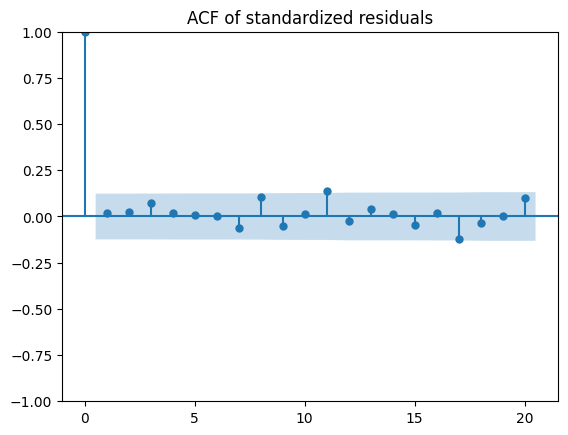

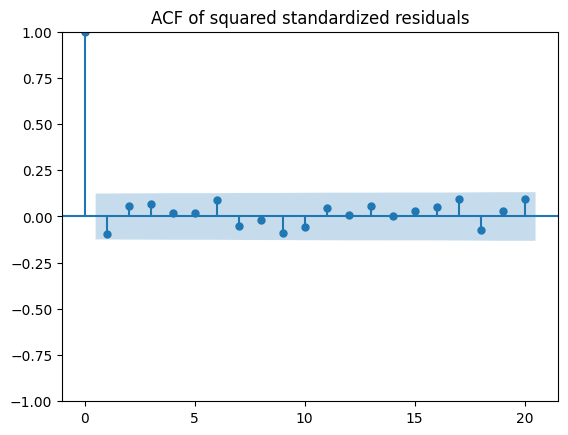

In [ ]:
resid_std = garch_res.resid / garch_res.conditional_volatility

plot_acf(resid_std, lags=20, title="ACF of standardized residuals");
plot_acf(resid_std**2, lags=20, title="ACF of squared standardized residuals");

#### ARMAX-GARCH Residual Diagnostics

The two plots provide diagnostic checks for the fitted ARMAX-GARCH model by examining the Autocorrelation Function (ACF) of the standardized residuals and the squared standardized residuals.

1.  **ACF of Standardized Residuals (Top Plot):**
    *   This plot checks the adequacy of the **mean equation** (ARMAX).
    *   At lag 0, the correlation is exactly 1.0, which is standard. For all subsequent lags (1 through 20), the autocorrelation coefficients fall well within the shaded blue 95% confidence interval.
    *   **Conclusion:** There is no significant remaining autocorrelation in the residuals. The ARMAX mean equation has successfully captured the linear dynamics and serial dependence in the data.

2.  **ACF of Squared Standardized Residuals (Bottom Plot):**
    *   This plot checks the adequacy of the **volatility equation** (GARCH).
    *   Similar to the first plot, all lags from 1 to 20 fall within the shaded confidence interval.
    *   **Conclusion:** There is no significant remaining autocorrelation in the squared residuals. This indicates that the GARCH model has successfully captured the volatility clustering (ARCH effects) present in the data.

**Overall Conclusion:** Both the mean and variance equations are well-specified, as the standardized residuals behave like white noise.

### Forecasting

In [62]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import pandas as pd
import numpy as np

def rolling_forecast_armax_garch(ret_train, x_macro_train,
                                 ret_test, x_macro_test,
                                 ar_p=0, ma_q=1,        # ARMAX orders
                                 garch_p=1, garch_q=1,  # GARCH orders
                                 dist="t",
                                 lag_exog=True):        # Added parameter to prevent look-ahead bias
    """
    Rolling (expanding-window) one-step-ahead forecast using a 2-step ARMAX-GARCH approach.
    Handles DatetimeIndex / Timestamp indices natively.
    """
    
    # --- 1. Handle Lagging to prevent look-ahead bias ---
    if lag_exog:
        # Combine train and test to shift safely across the boundary
        x_combined = pd.concat([x_macro_train, x_macro_test])
        x_combined_lagged = x_combined.shift(1)
        
        # Split back into train and test
        x_macro_train = x_combined_lagged.loc[x_macro_train.index]
        x_macro_test = x_combined_lagged.loc[x_macro_test.index]
        
        # Drop the first row of train (which is now NaN due to shifting) and align ret_train
        valid_idx = x_macro_train.dropna().index
        x_macro_train = x_macro_train.loc[valid_idx]
        ret_train = ret_train.loc[valid_idx]

    preds_mean, preds_var = [], []

    # Copy to avoid modifying originals
    current_ret = ret_train.copy()
    current_x   = x_macro_train.copy()

    # --- 2. Loop over test period ---
    for t in range(len(ret_test)):
        true_val = ret_test.iloc[t]
        true_index = ret_test.index[t]   # This is a Timestamp
        
        # Because of the shift above, next_x is now correctly X_{t-1}
        next_x = x_macro_test.iloc[[t]]  

        try:
            # Fit ARMAX mean model using statsmodels
            armax_model = ARIMA(current_ret, exog=current_x, order=(ar_p, 0, ma_q))
            armax_res = armax_model.fit()

            # Fit GARCH volatility model on the ARMAX residuals using arch
            am = arch_model(
                armax_res.resid,
                mean="Zero", # Mean dynamics are already extracted
                vol="GARCH",
                p=garch_p,
                q=garch_q,
                dist=dist,
                rescale=False
            )
            garch_res = am.fit(disp="off", show_warning=False)

            # One-step-ahead forecast
            # Mean forecast from ARMAX using X_{t-1}
            mean_forecast = armax_res.forecast(steps=1, exog=next_x).iloc[0]
            
            # Variance forecast from GARCH
            fcast = garch_res.forecast(horizon=1, reindex=False)
            var_forecast  = fcast.variance.iloc[-1, 0]

        except Exception as e:
            print(f"⚠️ Error at {true_index}: {e}")
            mean_forecast, var_forecast = np.nan, np.nan

        preds_mean.append(mean_forecast)
        preds_var.append(var_forecast)

        # --- 3. Expand rolling window safely ---
        new_ret = pd.Series([float(true_val)], index=[true_index])
        current_ret = pd.concat([current_ret, new_ret])
        
        # Append the lagged exogenous variables we just used to maintain alignment
        new_x = next_x.copy()
        new_x.index = [true_index]
        current_x = pd.concat([current_x, new_x])

    # Return forecasts as Series with original index
    preds_mean = pd.Series(preds_mean, index=ret_test.index, name="pred_mean")
    preds_var  = pd.Series(preds_var,  index=ret_test.index, name="pred_var")

    return preds_mean, preds_var

In [63]:
ts_data = pd.read_parquet('ts_data.parquet')

# Convert the date column to actual pandas datetime objects
ts_data['Date'] = pd.to_datetime(ts_data['Date'])

# Set the date column as the index of the dataframe
ts_data = ts_data.set_index('Date')

# 1. Define your y and X (Make sure they are aligned and have no NaNs)
top_6_features = ['Mkt - RF', 'SMB', 'HML', 'MOM', 'DP_HSI', 'diff_TBL_3MHIBOR']
X_selected = ts_data[top_6_features].dropna()
y = ts_data.loc[X_selected.index, 'HSI_Log_Return'] * 100

split_idx = int(len(y) * 0.8)

# Assuming y and X_selected are pandas Series/DataFrames
y_train = y.iloc[:split_idx]
X_train = X_selected.iloc[:split_idx]

y_test = y.iloc[split_idx:]
X_test = X_selected.iloc[split_idx:]

print(f"Training set size: {len(y_train)} | Testing set size: {len(y_test)}\n")

Training set size: 250 | Testing set size: 63



In [64]:
preds_mean, preds_var = rolling_forecast_armax_garch(
    y_train, X_train, y_test, X_test
)

print("Forecast complete.")

Forecast complete.


In [65]:
print("Predicted mean (ret_pred):")
print(preds_mean.describe(), "\n")


print("Predicted variance (ret_var):")
print(preds_var.describe(), "\n")

print("Test target (ret_test):")
print(y_test.describe())


Predicted mean (ret_pred):
count    63.000000
mean      1.265058
std       2.290388
min      -2.979973
25%      -0.290632
50%       1.120410
75%       2.021960
max      12.634777
Name: pred_mean, dtype: float64 

Predicted variance (ret_var):
count     63.000000
mean      39.055440
std       23.733652
min       18.725588
25%       24.850738
50%       31.391064
75%       44.767400
max      152.257068
Name: pred_var, dtype: float64 

Test target (ret_test):
count    63.000000
mean      0.202465
std       6.724447
min     -15.927172
25%      -3.768347
50%       0.181406
75%       3.313115
max      23.604853
Name: HSI_Log_Return, dtype: float64


### Output the result

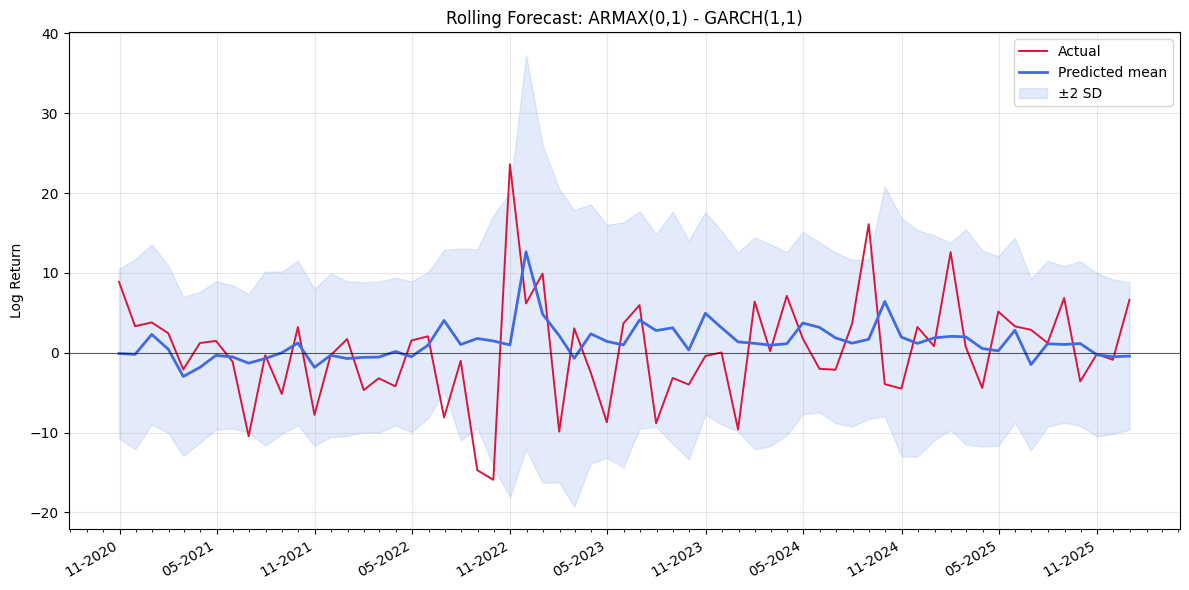

In [66]:
# 1. Align to a common index
# Since your index is already a DatetimeIndex now, we can use it directly
ix = y_test.index.union(preds_mean.index).union(preds_var.index).sort_values()
ret_al = y_test.reindex(ix)
mu_al  = preds_mean.reindex(ix)
var_al = preds_var.reindex(ix)
sd_al  = np.sqrt(var_al)

# 2. Plot using the DatetimeIndex directly
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ix, ret_al.values, color="crimson", lw=1.4, label="Actual")
ax.plot(ix, mu_al.values,  color="royalblue", lw=2.0, label="Predicted mean")

# Confidence band
mask = np.isfinite(mu_al.values) & np.isfinite(sd_al.values)
ax.fill_between(
    ix[mask],
    (mu_al.values - 2*sd_al.values)[mask],
    (mu_al.values + 2*sd_al.values)[mask],
    color="cornflowerblue", alpha=0.18, label="±2 SD"
)

# Cosmetics
ax.axhline(0, color="black", lw=0.8, alpha=0.6)
ax.set_title("Rolling Forecast: ARMAX(0,1) - GARCH(1,1)")
ax.set_ylabel("Log Return")

# Note: Removed ax.set_ylim(-0.2, 0.2) because your new data ranges from ~ -16 to +26.
# If you want to zoom in and ignore extreme spikes, uncomment and adjust the line below:
# ax.set_ylim(-20, 30) 

ax.grid(alpha=0.3)

# 3. Tick formatting
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # Tick every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) # Minor tick every month

fig.autofmt_xdate() # Slants dates slightly for readability

ax.legend(frameon=True)
fig.tight_layout()
plt.show()

#### Rolling Forecast Analysis: ARMAX(0,1) - GARCH(1,1)
* **Mean Prediction:** The predicted mean (blue line) remains relatively flat and hovers near zero throughout the out-of-sample period. It fails to capture the magnitude and timing of the large spikes and crashes present in the actual log returns (red line).
* **Volatility Modeling:** The GARCH(1,1) component successfully identifies periods of volatility clustering. This is evident around late 2022, where the \(\pm 2\) Standard Deviation confidence interval (light blue band) widens significantly in response to the massive spike and subsequent drop in actual returns.
* **Overall Fit:** Visually, the model acts more like a dynamic risk (variance) estimator rather than an accurate directional return predictor.


### Statistic Metrics

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib.patches import Patch

In [68]:
def calculate_oos_r2(y_true, y_pred, y_train_mean=None):
    """
    Calculates Out-of-Sample R-squared.
    """
    df = pd.DataFrame({'Actual': y_true, 'Pred': y_pred}).dropna()
    
    if df.empty:
        return np.nan

    sse_model = np.sum((df['Actual'] - df['Pred'])**2)
    
    if y_train_mean is not None:
        sse_baseline = np.sum((df['Actual'] - y_train_mean)**2)
        label = "OOS R² (vs Historical Mean)"
    else:
        sse_baseline = np.sum((df['Actual'] - df['Actual'].mean())**2)
        label = "OOS R² (vs Test Mean)"

    r2_oos = 1 - (sse_model / sse_baseline)
    
    print(f"--- {label} ---")
    print(f"Score: {r2_oos:.4f} ({(r2_oos*100):.2f}%)")
    if r2_oos > 0:
        print("Result: The model outperforms the baseline.")
    else:
        print("Result: The model underperforms the baseline (noise dominates).")
        
    return r2_oos

In [69]:
def compute_forecast_metrics(y_true, y_pred_mean, y_pred_var, y_train_mean=None):
    """
    Computes standard forecasting metrics including OOS R2 and Strategy Sharpe.
    """
    y = y_true.values if isinstance(y_true, pd.Series) else y_true
    yhat = y_pred_mean.values if isinstance(y_pred_mean, pd.Series) else y_pred_mean
    
    # Clip variance to prevent log(0) or division by zero issues
    var_clipped = np.clip(y_pred_var.values if isinstance(y_pred_var, pd.Series) else y_pred_var, 1e-12, None)
    sd = np.sqrt(var_clipped)

    metrics = {}
    metrics["RMSE"]  = np.sqrt(mean_squared_error(y, yhat))
    metrics["MAE"]   = mean_absolute_error(y, yhat)
    metrics["Bias"]  = float(np.nanmean(yhat - y))
    metrics["SignAcc"] = float(np.nanmean(np.sign(yhat) == np.sign(y)))
    metrics["Corr"]  = float(np.corrcoef(y, yhat)[0, 1])

    # 95% Prediction Interval Coverage
    cov95 = np.mean((y >= yhat - 1.96*sd) & (y <= yhat + 1.96*sd))
    metrics["PI95_coverage"] = float(cov95)
    
    # Gaussian Log Score
    metrics["LogScore_Gauss"] = float(np.mean(-0.5*(np.log(2*np.pi*sd**2) + ((y-yhat)**2)/(sd**2))))

    # Strategy Sharpe (annualized, assuming monthly data)
    ret_strat = np.sign(yhat) * y
    metrics["Sharpe_strat"] = float(np.nanmean(ret_strat) / np.nanstd(ret_strat) * np.sqrt(12))

    print("--- Forecast Metrics ---")
    for k, v in metrics.items():
        print(f"{k:>16}: {v:.4f}")
        
    print("\n")
    calculate_oos_r2(y, yhat, y_train_mean)
    
    return metrics

In [70]:
# 1. Compute all metrics
historical_mean = y_train.mean()
metrics_dict = compute_forecast_metrics(y_test, preds_mean, preds_var, y_train_mean=historical_mean)

--- Forecast Metrics ---
            RMSE: 6.9436
             MAE: 5.1683
            Bias: 1.0626
         SignAcc: 0.5556
            Corr: 0.0850
   PI95_coverage: 0.9048
  LogScore_Gauss: -3.3253
    Sharpe_strat: 0.1973


--- OOS R² (vs Historical Mean) ---
Score: -0.0834 (-8.34%)
Result: The model underperforms the baseline (noise dominates).


#### Statistical Metrics & Out-of-Sample Performance
* **Error Metrics:** The model exhibits a high RMSE (6.94) and MAE (5.16) relative to the scale of the returns. 
* **Predictive Power:** The correlation between predictions and actuals is extremely weak (0.0850), and the directional sign accuracy is only slightly better than a coin flip at 55.56%.
* **Out-of-Sample \(R^2\):** The OOS \(R^2\) is **-0.0833 (-8.33%)**. A negative \(R^2\) indicates that the model strictly underperforms a naive baseline that simply predicts the historical mean. As noted in the output, "noise dominates" the signal.
* **Interval Coverage:** The 95% Prediction Interval coverage is ~90.5%, meaning actual returns fall outside the expected bounds slightly more often than the model anticipates, suggesting potentially fatter tails than the assumed distribution accounts for.

In [71]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compare_to_persistence_baseline(actuals, model_preds):
    """
    Compares model predictions against a simple persistence baseline (naive forecast).
    
    Parameters:
    actuals (array-like): The actual observed values (y).
    model_preds (array-like): The predicted values from your model.
    """
    actuals = np.array(actuals)
    model_preds = np.array(model_preds)
    
    # Persistence baseline: predict the previous time step's actual value
    # We shift the actuals by 1. The first prediction is NaN, so we align from index 1.
    baseline_preds = actuals[:-1]
    aligned_actuals = actuals[1:]
    aligned_model_preds = model_preds[1:]
    
    # Calculate Metrics
    model_rmse = np.sqrt(mean_squared_error(aligned_actuals, aligned_model_preds))
    base_rmse = np.sqrt(mean_squared_error(aligned_actuals, baseline_preds))
    
    model_mae = mean_absolute_error(aligned_actuals, aligned_model_preds)
    base_mae = mean_absolute_error(aligned_actuals, baseline_preds)
    
    # Directional Accuracy (Sign Accuracy)
    model_sign_acc = np.mean(np.sign(aligned_model_preds) == np.sign(aligned_actuals))
    base_sign_acc = np.mean(np.sign(baseline_preds) == np.sign(aligned_actuals))
    
    print("--- Model vs. Persistence Baseline Comparison ---")
    print(f"RMSE      | Model: {model_rmse:.4f} | Baseline: {base_rmse:.4f}")
    print(f"MAE       | Model: {model_mae:.4f} | Baseline: {base_mae:.4f}")
    print(f"Sign Acc. | Model: {model_sign_acc:.4f} | Baseline: {base_sign_acc:.4f}")
    
    if model_rmse < base_rmse:
        print("\nResult: Model OUTPERFORMS the persistence baseline in RMSE.")
    else:
        print("\nResult: Model UNDERPERFORMS the persistence baseline in RMSE.")

compare_to_persistence_baseline(y_test, preds_mean)

--- Model vs. Persistence Baseline Comparison ---
RMSE      | Model: 6.9061 | Baseline: 9.5376
MAE       | Model: 5.1071 | Baseline: 6.9513
Sign Acc. | Model: 0.5645 | Baseline: 0.5806

Result: Model OUTPERFORMS the persistence baseline in RMSE.


In [72]:
def plot_feature_importance_abs(model_result, X_data):
    """
    Plots the absolute standardized impact of exogenous variables.
    Expects a statsmodels ARMAX/ARIMA fitted result object.
    """
    # 1. Extract Parameters
    params = model_result.params
    
    # Filter for exogenous variables (matches columns in X_data)
    exog_params = params[params.index.isin(X_data.columns)]
    
    if exog_params.empty:
        print("No matching exogenous variables found in model parameters.")
        return None
    
    # 2. Calculate Standard Deviations to normalize scale
    x_stds = X_data[exog_params.index].std()
    
    # 3. Compute Standardized Coefficients
    std_coeffs = exog_params * x_stds
    
    # 4. Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': exog_params.index,
        'Coefficient': exog_params.values,
        'Standardized_Impact': std_coeffs.values,
        'Abs_Impact': std_coeffs.abs().values
    }).sort_values('Abs_Impact', ascending=False)

    # 5. Plot
    plt.figure(figsize=(10, 6))
    
    # Color logic: Blue if positive, Red if negative
    colors = ['royalblue' if x > 0 else 'crimson' for x in importance_df['Standardized_Impact']]
    
    sns.barplot(
        x='Abs_Impact', 
        y='Feature', 
        data=importance_df, 
        palette=colors,
        hue='Feature',
        legend=False
    )
    
    # Add custom legend
    legend_elements = [
        Patch(facecolor='royalblue', label='Positive Correlation (+)'),
        Patch(facecolor='crimson', label='Negative Correlation (-)')
    ]
    plt.legend(handles=legend_elements, title="Direction of Effect")

    plt.title('Feature Importance: Absolute Standardized Impact\n(Magnitude of Change in Y given 1 SD shock to X)')
    plt.xlabel('Absolute Impact on Log Return (Standardized)')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return importance_df

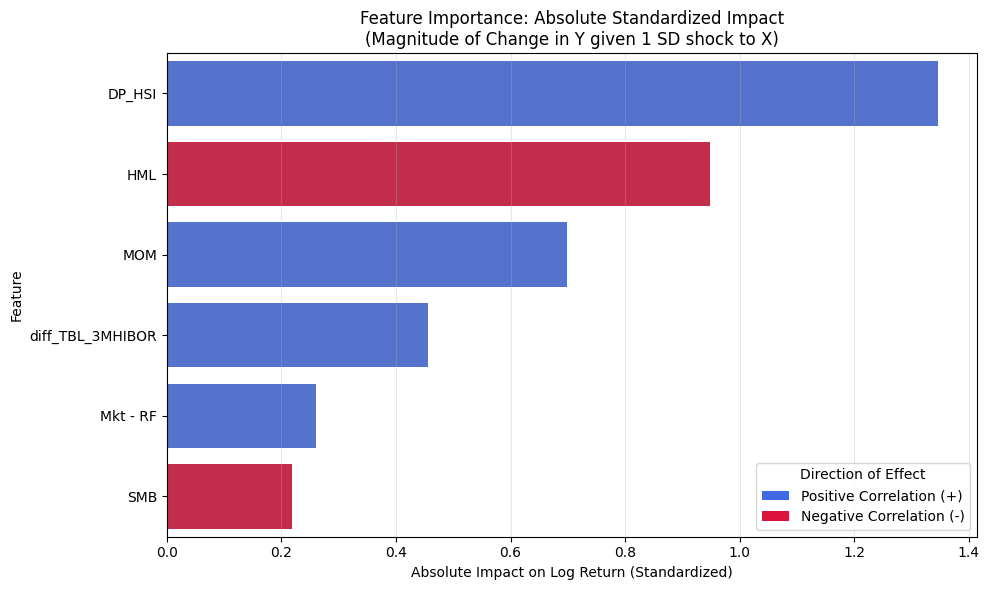

In [73]:
# 2. Plot Feature Importance
# Note: Because rolling forecasts generate a new model at every step, feature importance 
# is typically plotted using the model fitted on the ENTIRE training set.
from statsmodels.tsa.arima.model import ARIMA

# Fit a single model on the training data to extract overall feature importance
# Shift X_train and align indices with y_train
X_train_lagged = X_train.shift(1).dropna()
y_train_aligned = y_train.loc[X_train_lagged.index]

armax_full_train = ARIMA(y_train_aligned, exog=X_train_lagged, order=(0, 0, 1)).fit()

# Plot it (use X_train_lagged for feature importance since those are the actual features used)
importance_df = plot_feature_importance_abs(armax_full_train, X_train_lagged)

#### Feature Importance (Absolute Standardized Impact)
The feature importance chart reveals the most influential exogenous variables in the ARMAX equation based on a 1 Standard Deviation shock:
* **DP_HSI (Dividend Yield of HSI):** The strongest predictor, showing a positive correlation with log returns.
* **HML (Value Factor):** The second strongest driver, exhibiting a negative correlation.
* **MOM (Momentum):** The third strongest, showing a positive correlation.
* **Other Factors:** `diff_TBL_3MHIBOR` and `Mkt-RF` have moderate positive impacts, while `SMB` (Size Factor) has a minor negative impact.

**Conclusion:** While the exogenous variables (especially Dividend Yield and the Value factor) show structural importance, and the GARCH model captures volatility regimes, the combined ARMAX mean equation is unable to reliably forecast future returns, ultimately underperforming a simple historical mean baseline.